In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
length, width, height = 8, 8, 1 # in
divisions = 4
initial_temp = 293 # k
oven_temp = 450
target_temp = 370
delta_t = 0.1
rate_const = 4e-3

pan_temp = initial_temp * np.ones(shape=(length*divisions, width*divisions, height*divisions))

In [3]:
def average_temp(pan_temp):

    sum = np.sum(pan_temp.flatten())
    n_elements = np.shape(pan_temp.flatten())[0]
    return sum / n_elements

def min_temp(pan_temp):

    temps = pan_temp.flatten()
    return np.min(temps)

In [4]:
elapsed = 0
timesteps = []
timesteps.append(pan_temp)

while min_temp(pan_temp) < target_temp:
    updated_pan_temp = np.zeros_like(pan_temp)

    for x in range(length*divisions):
        for y in range(width*divisions):
            for z in range(height*divisions):

                T = pan_temp[x, y, z]
                Tx0 = pan_temp[x-1, y, z] if x != 0 else oven_temp
                Tx1 = pan_temp[x+1, y, z] if x != pan_temp.shape[0]-1 else oven_temp
                Ty0 = pan_temp[x, y-1, z] if y != 0 else oven_temp
                Ty1 = pan_temp[x, y+1, z] if y != pan_temp.shape[1]-1 else oven_temp
                Tz0 = pan_temp[x, y, z-1] if z != 0 else oven_temp
                Tz1 = pan_temp[x, y, z+1] if z != pan_temp.shape[2]-1 else oven_temp

                dx = 1 / divisions
                lapl = ((Tx1 - 2*T + Tx0) + (Ty1 - 2*T + Ty0) + (Tz1 - 2*T + Tz0)) / dx**2

                dT = rate_const * lapl * delta_t
                updated_pan_temp[x, y, z] = T + dT

    timesteps.append(updated_pan_temp)
    pan_temp = updated_pan_temp
    elapsed += delta_t

34.00000000000021


Text(0.5, 1.0, 'Average Internal Temperature')

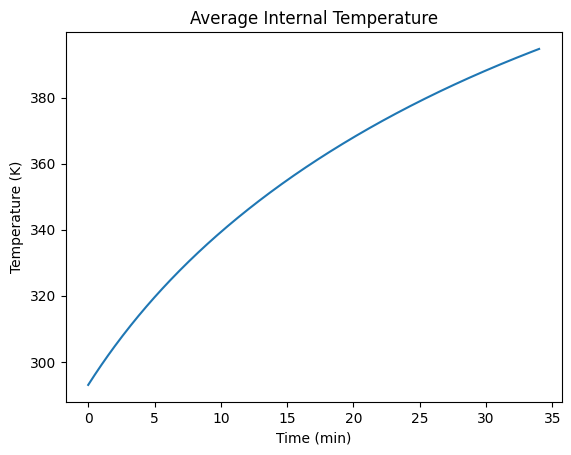

In [5]:
print(elapsed)
time = np.linspace(0, elapsed, len(timesteps))
temps = [average_temp(step) for step in timesteps]
plt.plot(time, temps)
plt.xlabel("Time (min)")
plt.ylabel("Temperature (K)")
plt.title("Average Internal Temperature")

In [ ]:
for i, state in enumerate(timesteps):
    fig, ax = plt.subplots(figsize=(length, width))
    z = int(height*divisions/2)
    for x in range(length*divisions):
        for y in range(width*divisions):
            T = state[x, y, z]
            temp_range = oven_temp - initial_temp
            color = ((T - initial_temp)/temp_range, 0, 1 - (T - initial_temp)/temp_range)
            plt.plot(x/divisions, y/divisions, color=color, marker="s", markersize=13)

    ax.set_aspect("equal")
    ax.set_title("Central Cross-Section of Brownies at time = " + str(int(i*delta_t)) + "min")
    ax.set_xlabel("Length (in)")
    ax.set_ylabel("Width (in)")
    fig.savefig('{steps:04}'.format(steps=i))
    plt.close()
